Collaborators: Steffen Pablo Krieg, Ferdinand Nilius, Benedikt Schneider, Johannes Schäfers

# Exercises week 38

**FYS-STK3155/4155, fall 2026 — deadline Friday September 18 at midnight.**

## Adaptive learning rates and stochastic gradient descent

The aim this week is that you extend last week's gradient descent code with
the adaptive methods AdaGrad, RMSProp and Adam, that you understand what each
of them does to the step and why their learning rate is not the learning rate
of plain gradient descent, and that you replace the full gradient by a
minibatch gradient with epochs and a learning-rate schedule. Everything here is
reused directly in parts f) and h) of Project 1. The code developed in the
Tuesday session (`week38tuesday.ipynb`, Cases 1 and 2) is meant to be reused,
and the Monday notebook (`week38.ipynb`) contains worked examples of every
piece.

After completing these exercises you will have

* derived the bias correction of Adam and the first step of the adaptive
  methods, and shown why they are insensitive to the scale of a feature;
* your own implementation of AdaGrad, RMSProp and Adam in the same
  three-function structure as last week's gradient descent, checked against
  the closed-form solutions of OLS and Ridge;
* scanned the learning rate for each method and related the windows you find
  to $2/\lambda_{\max}$ (Section 4.5) and to what $\gamma$ means for an
  adaptive method (Sections 4.8–4.12);
* a stochastic gradient descent loop with minibatches, epochs and the
  schedule of Eq. (4.40), and studied the batch size and the schedule
  (Section 4.7);
* applied all of it to the Runge function at degree 10, the problem nothing
  converged on last week.

Reading: Chapter 4, Sections 4.7–4.13 of the book; Goodfellow et al.,
Sections 8.1–8.5.

## The data

We keep last week's function,

$$
f(x) = 2 - x + 5x^2, \qquad x \in [-2, 2],
$$

with $n = 100$ points and Gaussian noise of standard deviation $0.5$, fitted
with polynomial features of degree 2 (an easy problem, $\kappa \approx 1.3$)
and degree 5 (a hard one, $\kappa \approx 520$). As last week, standardise the
columns of the design matrix, centre $\boldsymbol{y}$ and use no intercept
column; the closed-form OLS and Ridge solutions are your reference.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import jax
from jax import numpy as jnp
jax.config.update("jax_enable_x64", True)


def exercise_data(n=100, degree=2, noise=0.5, seed=2026):
    """Standardised polynomial design matrix (no intercept column) and centred targets."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-2.0, 2.0, n)
    y = 2.0 - x + 5.0 * x**2 + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()

def closed_form(X, y, lam=0.0):
    """(X^T X + n lambda I)^-1 X^T y, the 1/n convention of Eq. (3.95)."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

def cost(theta, X, y, lam=0.0):
    """Eqs. (4.12) and (4.16)."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta

def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): your analytical gradient from last week (or jax.grad of cost)."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

def hessian_eigs(X, lam=0.0):
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))

X2, y2 = exercise_data(degree=2)
X5, y5 = exercise_data(degree=5)
for X in (X2, X5):
    eigs = hessian_eigs(X)
    print(f"degree {X.shape[1]}: kappa = {eigs.max() / eigs.min():.1f}, 2/lambda_max = {2 / eigs.max():.3f}")

degree 2: kappa = 1.3, 2/lambda_max = 0.894
degree 5: kappa = 520.3, 2/lambda_max = 0.354


## Exercise 1: what the adaptive methods do to the step (analytical)

The three adaptive methods replace the single learning rate $\gamma$ by a
per-coordinate step $\gamma/\sqrt{v_j}$, where $v_j$ estimates the second
moment of the gradient in coordinate $j$ (Section 4.8).

### 1a)

Unroll the RMSProp recursion of Eq. (4.47),
$\boldsymbol{v}_t = \rho\,\boldsymbol{v}_{t-1} + (1-\rho)\boldsymbol{g}_t^2$ with
$\boldsymbol{v}_0 = \boldsymbol{0}$, to obtain Eq. (4.49),
$\boldsymbol{v}_t = (1-\rho)\sum_{j=1}^{t}\rho^{\,t-j}\boldsymbol{g}_j^2$, and show
that the weights sum to $1 - \rho^t$. After how many steps has a gradient's
weight fallen below $1/e$ of its initial weight, for $\rho = 0.9$ and
$\rho = 0.99$? Compare with AdaGrad's sum, Eq. (4.42), whose weights are all
one.

### 1b)

Now Adam. Assume the gradient is stationary with $\mathbb{E}[g^2]$ constant.
Take the expectation of the unrolled second moment of Eq. (4.52) and derive
Eq. (4.53), $\mathbb{E}[v_t] = (1-\beta_2^{\,t})\,\mathbb{E}[g^2]$. Do the same
for the first moment with $\beta_1$. Explain why dividing by $1-\beta_i^t$,
Eq. (4.54), removes the bias exactly, and evaluate the correction factors at
$t = 1$, $t = 10$ and $t = 1000$ for the default $\beta_1 = 0.9$,
$\beta_2 = 0.999$.

### 1c)

Show that the first step of Adam, Eq. (4.55) at $t = 1$, is
$\Delta\theta_j = -\gamma\,\mathrm{sign}(g_{1,j})$ (up to $\epsilon$),
independent of the size of the gradient, and that the same holds for AdaGrad.
What is the first step of RMSProp, which has no bias correction, with
$\rho = 0.99$? What does this tell you about the meaning of $\gamma$ for these
methods, compared with plain gradient descent? Without bias correction, by
what factor would Adam's first step be too long?

### 1d)

Multiply one feature (one column of $\boldsymbol{X}$) by a constant $c$. Show
that the corresponding component of the gradient of the OLS cost scales by
$c$ and that the AdaGrad/RMSProp/Adam step in that coordinate is unchanged,
whereas the plain gradient descent step scales by $c$ (and the stability bound
$2/\lambda_{\max}$ moves). Why does this *not* mean that standardising the
data is unnecessary for the adaptive methods? (Hint: the Tuesday session's
rotated bowl.)

Exercise 1.a):

Proof by induction: start with calculating $v_1$ from the given $v_0$ using both formulas:

$$
v_1 = (1-p) \sum_{j=1}^1 p^{1-j} g_j^2 = (1-p) g_1^2 \newline
v_1 = p \cdot v_0 + (1-p) g_1^2 = (1-p) g_1^2
$$

Furthermore it has to be shown that the formula holds for t, if it is given that it holds for t-1:

$$
v_t = (1-p) \sum_{j=t}^1 p^{t-j} g_j^2 = (1-p) g_t^2 + \sum_{j=1}^{t-1} p^{t-j} g_j^2 - p^{t-j+1} g_j^2 = (1-p) g_t^2 + p \cdot \sum_{j=1}^{t-1} p^{t-j-1} g_j^2 - p^{t-j} g_j^2
$$

The second part of this is just the same formula we started with but using t-1 instead of t:
$$
(1-p) g_t^2 + p \cdot \sum_{j=1}^{t-1} p^{t-j-1} g_j^2 - p^{t-j} g_j^2 = (1-p) g_t^2 + p \cdot \sum_{j=1}^{t-1} p^{(t-1)-j} g_j^2 - p^{(t-1)-j+1} g_j^2 = (1-p) g_t^2 + p \cdot (1-p) \sum_{j=1}^{t-1} p^{(t-1)-j} g_j^2 = (1-p) g_t^2 + p \cdot v_{t-1}
$$

Therefore the two formulas are identical.

The sum of the weights is given by $(1-p)\sum_{j=1}^{t} p^{t-j}$ which can be reforemed to show:
$$
(1-p)\sum_{j=1}^{t} p^{t-j} = (1-p) (-p^t + \sum_{j=0}^{t} p^{t-j}) = (1-p) (-p^t) (1 + \sum_{j=0}^{t} \frac{1}{p^{j}}) \newline
= (1-p) (-p^t) (1- \frac{1-p^-(t+1)}{1-p^{-1}}) = (1-p) (-p^t) (\frac{1-p^{-1}}{1-p^{-1}}- \frac{1-p^{-(t+1)}}{1-p^{-1}}) = (1-p) (-p^t) (\frac{p^{-(t+1)}-p^{-1}}{1-p^{-1}})\newline
= (1-p) (-p^t) (\frac{p^{-(t)}-1}{p-1}) = (1-p) (-p^t) (p^{-t}-1) (p-1)^{-1} =  (1-p) (-1+p^{t}) (p-1)^{-1} = 1-p^t
$$

To find how many iterations it takes until a gradients weight has fallen to 1/e of it´s original value, the weight of the gradient has to be set equal to 1/e and the equation needs to be solved for the difference between the current t and the iteration j:

$$
\frac{1}{e} \ge p^{t-j} \newline
-1 \ge (t-j) \ln{p} \newline
\frac{-1}{\ln{p}} \le (t-j) \newline
$$

For p = 0.9 it therefore takes 10 iterations, while for p = 0.99 it takes 100 iterations until the weight has fallen below 1/e. (See printout below)

In [8]:
print("The required number of iterations before the weight of a gradient falls to 1/e of its intial weight for p = 0.9 is: ", int(np.ceil(-1/np.log(0.9))))
print("The required number of iterations before the weight of a gradient falls to 1/e of its intial weight for p = 0.99 is: ", int(np.ceil(-1/np.log(0.99))))

The required number of iterations before the weight of a gradient falls to 1/e of its intial weight for p = 0.9 is:  10
The required number of iterations before the weight of a gradient falls to 1/e of its intial weight for p = 0.99 is:  100


Exercise 1.d):

For plain OLS: 
$$
\nabla C_{OLS} = 2/n X^T (X \theta -y ) = 2/n X^T (\hat{y} - y) 
$$
Therefore, if we multiply one column of X with a constant c, the element of the gradient of the row that corresponds to said column will also be multiplied by c.


AdaGrad uses the following update formula for every parameter: 
$$
\theta_{t+1,j} = \theta_{t,j} - \frac{\gamma}{\sqrt{r_{t,j}}} g_{t,j} \  with \  r_{t,j} = r_{t-1,j} + g_{t,j}^2
$$
Therefore if the gradient is scaled by a factor of c, both the square root of r and g will grow in the same manner. The step size therefore stays unchanged.


RMSProp uses the following per parameter formula: 
$$
\theta_{t+1,j} = \theta_{t,j} - \frac{\gamma}{\sqrt{v_{t,j}}} g_{t,j} \ with \  v_{t,j} = p v_{t-1,j} + (1-p)g_{t,j}^2
$$
A similar pattern arises here: Even if the component of the gradient enlarges, the divisor v will rise in the same manner, therefore leaving the step size unchanged.

Adam has a similar update to RMSProp with momentum added additionally:
$$
\theta_{t+1,j} = \theta_{t,j} - \frac{\alpha}{\sqrt{v_{t,j}}} m_{t,j} \ with \ v_{t,j} = p v_{t-1,j} + (1-p)g_{t,j}^2 \  and \  m_{t,j} = \beta m_{t-1,j} + (1-\beta) g_{t,j}
$$

It can be seen again that even if the individual component of g is raised for every step this does not matter as it is divide by a value that scales in the same manner.

For plain Gradienet descent only the gradient is used in the update formula, without having a scaling factor, preventing the update of the step being too large.

One can not rely on these scaling factors however, as all of these methods only use an approximation of the H matrix and not the exact value. This can be especially relevant when string correlations between features arise, leading to a strongly non diagonal H. If this happens and the data is not scaled beforehand, the adaptivity of RMSProp / Adam / AdaGrad can not capture this leading to worse overall performance of the methods.

## Exercise 2: implementing AdaGrad, RMSProp and Adam

Extend last week's code with one step function that holds all five
optimisers. The template below has the update rules to fill in; keep the
gradient as an argument so that the analytical gradient and `jax.grad` are
interchangeable, as in part e) of Project 1.

In [19]:
beta = 0.9
rho = 0.99
beta1 = 0.9
beta2 = 0.999


def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t (t = 1, 2, ...), Eqs. (4.10), (4.28),
    (4.42)-(4.45), (4.47)-(4.48) and (4.51)-(4.55).  state carries the running quantities."""
    if method == "plain":
        return theta - gamma * g, state
    if method == "momentum":
        v = beta * state.get("v", 0.0) + gamma * g                # Eq. (4.28)                               
        state["v"] = v
        return theta - v, state
    if method == "adagrad":
        r = state.get("r", 0.0) + g * g                           # Eq. (4.42)
        state["r"] = r
        return theta - gamma * g / (np.sqrt(r) + eps), state      # Eq. (4.45) 
    if method == "rmsprop":
        r = rho * state.get("r", 0.0) + (1.0 - rho) * g * g       # Eq. (4.47)
        state["r"] = r
        return theta - gamma * g / (np.sqrt(r) + eps), state      # Eq. (4.48)
    if method == "adam":
        m = beta1 * state.get("m", 0.0) + (1.0 - beta1) * g       # Eq. (4.51)
        r = beta2 * state.get("r", 0.0) + (1.0 - beta2) * g * g   # Eq. (4.52)
        state["m"], state["r"] = m, r
        m_hat = m / (1.0 - beta1**t)                              # Eq. (4.54)
        r_hat = r / (1.0 - beta2**t)
        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state   # Eq. (4.55)
    raise ValueError(f"unknown method {method}")


def optimise(grad, theta0, method, gamma, num_iters=1000, tol=0.0, **kw):
    """Run one optimiser from theta0 with the full gradient; returns all iterates."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history)


### 2a)

Run all five methods on the degree-2 data for OLS and for Ridge with
$\lambda = 0.01$ (remember the $n\lambda\boldsymbol{I}$ of the closed form).
Use $\gamma = 0.5$ for plain gradient descent and momentum and try
$\gamma \in \{0.01, 0.1\}$ for the adaptive methods. Do all of them converge to
the closed-form solution? Plot the distance
$\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|$ against the iteration for
each method.

### 2b)

Repeat for the degree-5 data ($\kappa = 520$), with $\gamma = 0.9 \cdot 2/\lambda_{\max}$
for plain descent and momentum. Report the number of iterations to reach
$\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\| < 10^{-6}$ for each method,
and identify the method that does not get there at a constant $\gamma$.
Explain why, using your result from exercise 1c).

### 2c)

Check one method against a library implementation: for the degree-2 OLS
problem, run `optax.adam` (or `torch.optim.Adam`, or any other) with the same
$\gamma$, $\beta_1$, $\beta_2$ and $\epsilon$ from the same starting point, and
compare the first ten iterates with your own. They should agree to rounding.
If they do not, the usual suspects are the bias correction and the placement
of $\epsilon$ (inside or outside the square root).

In [16]:
# Your code for exercise 2 here

def method_gradient_descent(
        X: np.ndarray, 
        y: np.ndarray, 
        method: str = "plain",
        lam: float = 0.0, 
        max_iterations: int = 1e5, 
        learning_rate: float = 0.01,
        tolerance: float = 1e-6, 
        initial_theta: np.ndarray | None = None, 
        theta_hat: np.ndarray | None = None,
        gradient: str = "analytic",
        **kw
    ) -> tuple[np.ndarray, np.ndarray]:
    """
    Perform gradient descent with given method on the given data.

    Parameters:
    -----------
    X : array-like, shape (n_samples, n_features)\\
        The normalized design matrix
    y : array-like, shape (n_samples,)\\
        The centered target values
    lam : float, optional\\
        Regularization parameter (lambda) for ridge regression. Default is 0 (OLS).
    method : str, optional\\
        Method for gradient descent optimisation step to choose. Default is "plain".
        (Options are "plain", "momentum", "adagrad", "rmsprop", "adam")
    learning_rate : float, optional\\
        Learning rate (gamma) for gradient descent. Default is 0.01.
    max_iterations : int, optional\\
        Maximum number of iterations for gradient descent. Default is 1e5.
    tolerance : float, optional\\
        Tolerance for convergence. Default is 1e-6.
    initial_theta: np.ndarray, shape (n_features, ) | None, optional\\
        Initial guess for theta. If None, initialized to zeros.
    theta_hat : np.ndarray, shape (n_features, ) | None, optional\\
        Precomputed theta_hat for ridge regression. If None, computed internally.
    gradient : String, optional\\
        The type of gradient to use. Either "analytic" or "autograd". Default is "analytic".
    **kw : dict, optional\\
        Additional keyword arguments for the optimiser_step function.
        Useful for passing parameters like beta, rho, beta1, beta2, eps for specific methods.
        
    Returns:
    --------
    theta_history : np.ndarray, shape (max{# of iterations till convergence, max_iterations}, n_features)\\
        The estimated parameters theta at each gradient descent step.
    distance_history : np.ndarray, shape (max{# of iterations till convergence, max_iterations})\\
            The evaluated distance at each gradient descent step.
                If theta_hat (optional) is given, the distance is evaluated as ||θ - θ̂ ||₂
                otherwise the distance is evaluated as ||θₖ₊₁ - θₖ||₂ 

    (The content of the docstring is generated by Copilot inline suggestions and was reviewed and edited by the user.)
    """

    n_samples, n_features = X.shape

    theta = initial_theta if initial_theta is not None else np.zeros(n_features)
    state = {}

    theta_history = np.array([theta])
    distance_history = np.array([])

    match gradient:
        # choose between analytic gradient or automatic differentiation
        # note: for lam=0 Ridge -> OLS
        case "analytic":
            gradient_fct = lambda theta: 2.0 / len(y) * X.T @ (X @ theta - y) + 2.0 * lam * theta
        case "autograd":
            autograd = jax.grad(cost)
            gradient_fct = lambda theta: autograd(jnp.asarray(theta), X=jnp.asarray(X), y=jnp.asarray(y), lam=lam)
        case _:
            raise ValueError("Parameter gradient (String) has to have the value 'analytical' (analytical gradient for ridge) or 'autograd' (automatic differentiation for ridge)!")

    for t in range(1, int(max_iterations) + 1):
        grad = gradient_fct(theta)

        # update theta (plain gradient descent step)
        theta_new, state_new = optimiser_step(method, theta, grad, state, t, learning_rate, **kw)
        theta_history = np.append(theta_history, theta_new.reshape(1, -1), axis=0)
        
        # approximate the distance, either by 
        # the explicit distance to the closed form result
        # or by the difference θk+1 - θk
        distance = np.linalg.norm(theta_new - theta) if theta_hat is None else np.linalg.norm(theta_new - theta_hat)
        distance_history = np.append(distance_history, distance)

        if distance < tolerance:
            break

        theta = theta_new
        state = state_new

    return theta_history, distance_history

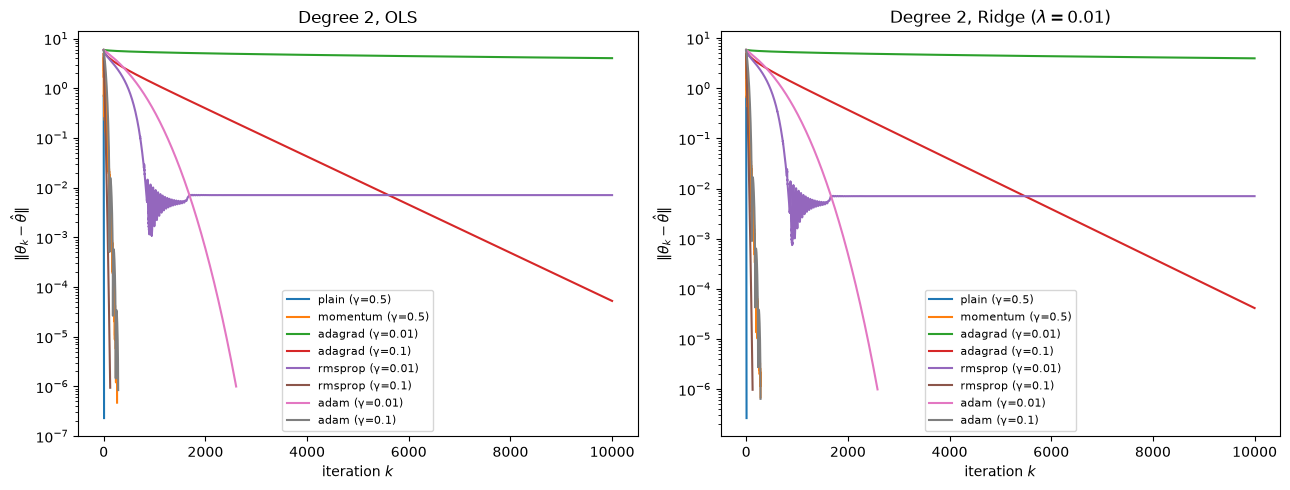

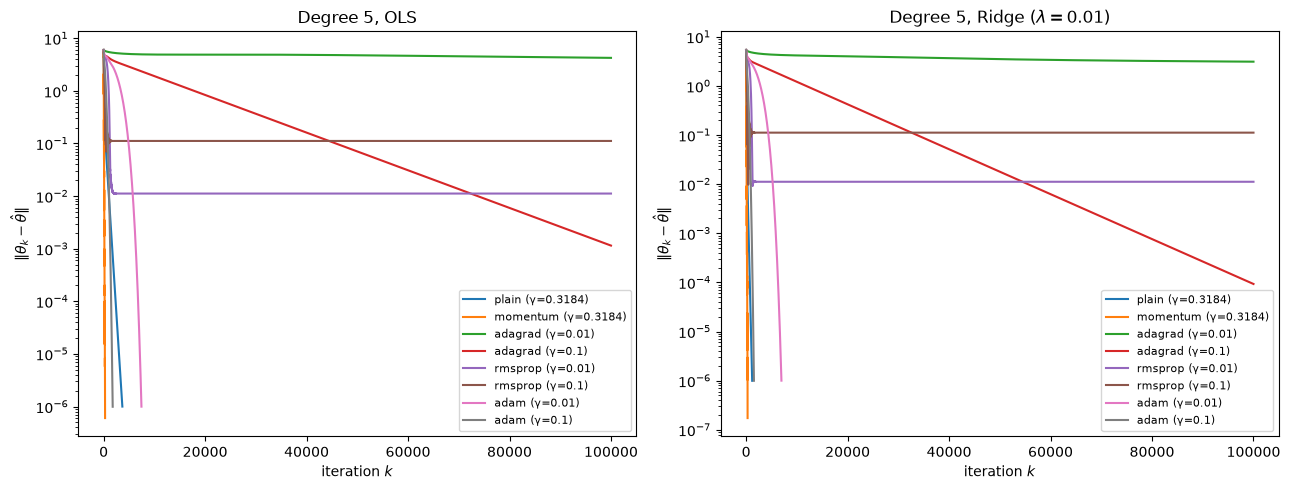

--- Degree 5, OLS ---
method                    | iterations to reach tol
plain (γ=0.3184)          | 3689
momentum (γ=0.3184)       | 284
adagrad (γ=0.01)          | >100000 (not converged)
adagrad (γ=0.1)           | >100000 (not converged)
rmsprop (γ=0.01)          | >100000 (not converged)
rmsprop (γ=0.1)           | >100000 (not converged)
adam (γ=0.01)             | 7452
adam (γ=0.1)              | 1785
--- Degree 5, Ridge ---
method                    | iterations to reach tol
plain (γ=0.3184)          | 1189
momentum (γ=0.3184)       | 286
adagrad (γ=0.01)          | >100000 (not converged)
adagrad (γ=0.1)           | >100000 (not converged)
rmsprop (γ=0.01)          | >100000 (not converged)
rmsprop (γ=0.1)           | >100000 (not converged)
adam (γ=0.01)             | 6956
adam (γ=0.1)              | 1537
  k | own theta                                | optax theta                              | max abs diff
  0 | [0. 0.]                                  | [0. 0.]           

In [17]:
# the following plotting code is generated by Claude Sonnet 5 
# prompted by giving code and exercise and asking for a plotting code
# and reviewed and edited by the usesr

import optax

methods_fixed = ["plain", "momentum"]
methods_adaptive = ["adagrad", "rmsprop", "adam"]
gammas_adaptive = [0.01, 0.1]


def run_all_methods(X, y, lam, gamma_fixed, max_iterations=int(1e4), tolerance=1e-6):
    """Run all five methods (fixed gamma for plain/momentum, both gammas for
    the adaptive methods) and return {label: (theta_history, distance_history)}."""
    theta_hat = closed_form(X, y, lam=lam)
    runs = {}
    for method in methods_fixed:
        label = f"{method} (γ={gamma_fixed:.4g})"
        runs[label] = method_gradient_descent(
            X, y, method=method, lam=lam, learning_rate=gamma_fixed,
            max_iterations=max_iterations, tolerance=tolerance, theta_hat=theta_hat,
        )
    for method in methods_adaptive:
        for gamma in gammas_adaptive:
            label = f"{method} (γ={gamma})"
            runs[label] = method_gradient_descent(
                X, y, method=method, lam=lam, learning_rate=gamma,
                max_iterations=max_iterations, tolerance=tolerance, theta_hat=theta_hat,
            )
    return runs


def plot_distance(runs, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    for label, (theta_hist, dist_hist) in runs.items():
        ax.plot(dist_hist, label=label)
    ax.set_yscale("log")
    ax.set_xlabel("iteration $k$")
    ax.set_ylabel(r"$\|\theta_k - \hat\theta\|$")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.figure.tight_layout()
    return ax


# 2a)
lam_ridge = 0.01

runs_ols_2 = run_all_methods(X2, y2, lam=0.0, gamma_fixed=0.5)
runs_ridge_2 = run_all_methods(X2, y2, lam=lam_ridge, gamma_fixed=0.5)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_distance(runs_ols_2, "Degree 2, OLS", ax=axes[0])
plot_distance(runs_ridge_2, r"Degree 2, Ridge ($\lambda=0.01$)", ax=axes[1])
plt.show()

# 2b)
lam_max_5 = hessian_eigs(X5, lam=0.0).max()
gamma_fixed_5 = 0.9 * 2 / lam_max_5

runs_ols_5 = run_all_methods(X5, y5, lam=0.0, gamma_fixed=gamma_fixed_5,
                              max_iterations=int(1e5))
runs_ridge_5 = run_all_methods(X5, y5, lam=lam_ridge, gamma_fixed=gamma_fixed_5,
                                max_iterations=int(1e5))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_distance(runs_ols_5, "Degree 5, OLS", ax=axes[0])
plot_distance(runs_ridge_5, r"Degree 5, Ridge ($\lambda=0.01$)", ax=axes[1])
plt.show()


# report iterations-to-tolerance
def report_iterations(runs, tol=1e-6):
    print(f"{'method':25s} | iterations to reach tol" )
    for label, (theta_hist, dist_hist) in runs.items():
        converged = dist_hist[-1] < tol
        n_iter = len(dist_hist)
        status = f"{n_iter}" if converged else f">{n_iter} (not converged)"
        print(f"{label:25s} | {status}")


print("--- Degree 5, OLS ---")
report_iterations(runs_ols_5)
print("--- Degree 5, Ridge ---")
report_iterations(runs_ridge_5)

#2c)
def compare_adam_with_optax(X, y, lam=0.0, gamma=0.1,
                             beta1=0.9, beta2=0.999, eps=1e-8, n_iter=10):
    n, p = X.shape
    theta0 = np.zeros(p)

    # your implementation (tolerance disabled so it always runs n_iter steps)
    theta_hist_own, _ = method_gradient_descent(
        X, y, method="adam", lam=lam, learning_rate=gamma,
        max_iterations=n_iter, tolerance=-1.0, initial_theta=theta0.copy(),
        beta1=beta1, beta2=beta2, eps=eps,
    )

    # optax reference
    optimizer = optax.adam(learning_rate=gamma, b1=beta1, b2=beta2, eps=eps)
    theta = jnp.asarray(theta0)
    opt_state = optimizer.init(theta)
    grad_fn = jax.grad(cost)

    theta_hist_optax = [np.array(theta)]
    for _ in range(n_iter):
        g = grad_fn(theta, X=jnp.asarray(X), y=jnp.asarray(y), lam=lam)
        updates, opt_state = optimizer.update(g, opt_state, theta)
        theta = optax.apply_updates(theta, updates)
        theta_hist_optax.append(np.array(theta))
    theta_hist_optax = np.array(theta_hist_optax)

    print(f"{'k':>3} | {'own theta':40s} | {'optax theta':40s} | max abs diff")
    for k in range(n_iter + 1):
        diff = np.max(np.abs(theta_hist_own[k] - theta_hist_optax[k]))
        print(f"{k:3d} | {np.array2string(theta_hist_own[k], precision=6):40s} "
              f"| {np.array2string(theta_hist_optax[k], precision=6):40s} | {diff:.2e}")

    return theta_hist_own, theta_hist_optax

theta_own, theta_optax = compare_adam_with_optax(X2, y2, lam=0.0, gamma=0.1)

## Exercise 3: the learning rate means something different to each method

### 3a)

For the degree-5 OLS problem, scan $\gamma$ over a logarithmic grid from
$10^{-3}$ to $1$ (about fifteen values) for each of the five methods, and
record the number of iterations to $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\| < 10^{-6}$
(or "did not converge" within 20 000 iterations). Plot iterations against
$\gamma$ for all methods in one figure, on logarithmic axes.

### 3b)

Discuss the figure: where does each method's window of usable $\gamma$ start
and end, and how do the edges relate to $2/\lambda_{\max}$ (plain descent),
$2(1+\beta)/\lambda_{\max}$ (momentum), and to the fact that the adaptive
methods take steps of length at most $\gamma$ per coordinate? Which method is
the least sensitive to $\gamma$, and is it also the fastest at its best
$\gamma$?

### 3c)

Book Table 4.1 and Figure 4.7 compare the five methods at three learning
rates on a problem with $\kappa = 12$ and find that the ranking reverses
between $\gamma = 0.01$ and $\gamma = 0.5$. Reproduce this behaviour on your
degree-2 data (where $\kappa = 1.3$): which method is best at each $\gamma$, and
what is the lesson for how optimisers should be compared in Project 1?

c:\Users\Johannes\Projects\MachineLearningUiO\.venv\Lib\site-packages\numpy\linalg\_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
C:\Users\Johannes\AppData\Local\Temp\ipykernel_22032\3518337135.py:70: RuntimeWarning: overflow encountered in matmul
  gradient_fct = lambda theta: 2.0 / len(y) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\Johannes\AppData\Local\Temp\ipykernel_22032\3518337135.py:70: RuntimeWarning: invalid value encountered in matmul
  gradient_fct = lambda theta: 2.0 / len(y) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\Johannes\AppData\Local\Temp\ipykernel_22032\3518337135.py:70: RuntimeWarning: invalid value encountered in multiply
  gradient_fct = lambda theta: 2.0 / len(y) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\Johannes\AppData\Local\Temp\ipykernel_22032\1724544867.py:14: RuntimeWarning: overflow encountered in multiply
  v = beta * state.get("v", 0.0) + gamma * g                # Eq. (4.28)
C:\Users\Joha

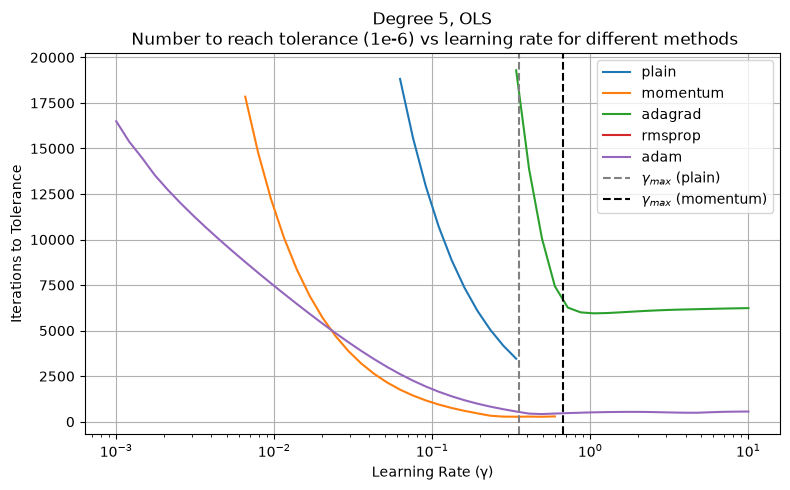

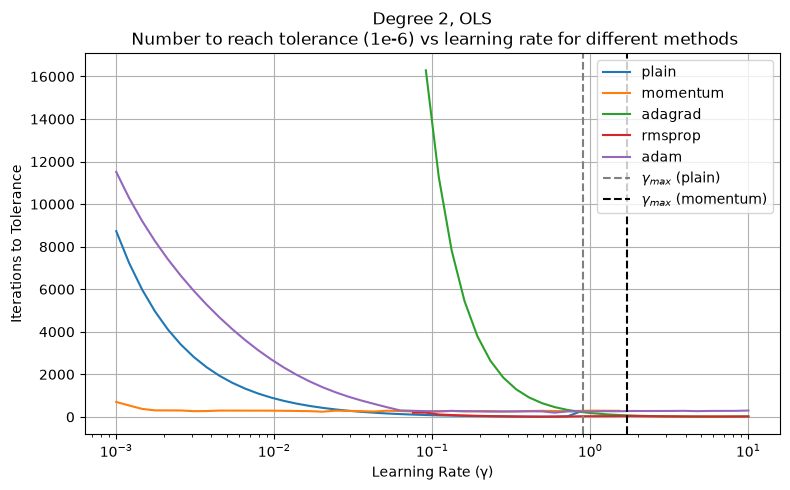

Method     | γ=0.01   | γ=0.1    | γ=0.5   
-------------------------------------------
plain      |   1.0853 |   0.3432 |   0.3432
momentum   |   0.3438 |   0.3435 |   0.3439
adagrad    |  32.0949 |  17.0234 |   0.4661
rmsprop    |  15.8011 |   0.3432 |   0.3432
adam       |  23.8587 |   0.3493 |   0.3440

Analytical minimum: 0.34320

Best method per γ:
  γ=0.01: momentum (0.3438)
  γ=0.1: plain (0.3432)
  γ=0.5: plain (0.3432)


In [20]:
# Your code for exercise 3 here

gamma_values =np.logspace(-3, 1, num=50)

methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]

iterations_to_tolerance = {method: np.array([]) for method in methods}

gamma_max_plain = 2 / hessian_eigs(X5, lam=0.0).max()  # maximum learning rate for plain gradient descent
gamma_max_momentum = 2 * (1 + beta) / hessian_eigs(X5, lam=0.0).max()  # maximum learning rate for momentum gradient descent


for gamma in gamma_values:
    for method in methods:
        theta_hist, dist_hist = method_gradient_descent(
            X5, y5, 
            method=method, 
            lam=0.0, 
            learning_rate=gamma,
            max_iterations=int(20000), 
            tolerance=1e-6,
            theta_hat=closed_form(X5, y5, lam=0.0)
        )
        iterations_to_tolerance[method] = np.append(iterations_to_tolerance[method], len(dist_hist))

fig, ax = plt.subplots(figsize=(8, 5))
for method in methods:
    divergence_mask = iterations_to_tolerance[method] < 20000  # exclude non-converged runs
    ax.plot(gamma_values[divergence_mask], iterations_to_tolerance[method][divergence_mask], label=method)

ax.axvline(gamma_max_plain, color='gray', linestyle='--', label=r'$\gamma_{max}$ (plain)')
ax.axvline(gamma_max_momentum, color='black', linestyle='--', label=r'$\gamma_{max}$ (momentum)')
ax.set_xlabel("Learning Rate (γ)")
ax.set_ylabel("Iterations to Tolerance")
ax.set_xscale("log")

ax.set_title("Degree 5, OLS\n Number to reach tolerance (1e-6) vs learning rate for different methods")

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


# 3c)

# same on the 2d data

gamma_values =np.logspace(-3, 1, num=50)

methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]

iterations_to_tolerance = {method: np.array([]) for method in methods}

gamma_max_plain = 2 / hessian_eigs(X2, lam=0.0).max()  # maximum learning rate for plain gradient descent
gamma_max_momentum = 2 * (1 + beta) / hessian_eigs(X2, lam=0.0).max()  # maximum learning rate for momentum gradient descent


for gamma in gamma_values:
    for method in methods:
        theta_hist, dist_hist = method_gradient_descent(
            X2, y2, 
            method=method, 
            lam=0.0, 
            learning_rate=gamma,
            max_iterations=int(20000), 
            tolerance=1e-6,
            theta_hat=closed_form(X2, y2, lam=0.0)
        )
        iterations_to_tolerance[method] = np.append(iterations_to_tolerance[method], len(dist_hist))

fig, ax = plt.subplots(figsize=(8, 5))
for method in methods:
    divergence_mask = iterations_to_tolerance[method] < 20000  # exclude non-converged runs
    ax.plot(gamma_values[divergence_mask], iterations_to_tolerance[method][divergence_mask], label=method)

ax.axvline(gamma_max_plain, color='gray', linestyle='--', label=r'$\gamma_{max}$ (plain)')
ax.axvline(gamma_max_momentum, color='black', linestyle='--', label=r'$\gamma_{max}$ (momentum)')
ax.set_xlabel("Learning Rate (γ)")
ax.set_ylabel("Iterations to Tolerance")
ax.set_xscale("log")
ax.set_title("Degree 2, OLS\n Number to reach tolerance (1e-6) vs learning rate for different methods")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

# the follwoing table is given by Claude Sonnet 5 prompted by giving the table from the book and asking to recreate the table with my results and reviewed and edited by the user

gammas_3c = [0.01, 0.1, 0.5]
n_iterations_3c = 100  # matches the book's "100 epochs"; full-batch here, so just 100 steps

theta_hat_2 = closed_form(X2, y2, lam=0.0)
cost_min = cost(theta_hat_2, X2, y2, lam=0.0)

table_3c = {method: [] for method in methods}

for gamma in gammas_3c:
    for method in methods:
        theta_hist, dist_hist = method_gradient_descent(
            X2, y2, method=method, lam=0.0, learning_rate=gamma,
            max_iterations=n_iterations_3c, tolerance=-1.0,  # disable early stop
            theta_hat=theta_hat_2,
        )
        theta_final = theta_hist[-1]
        table_3c[method].append(cost(theta_final, X2, y2, lam=0.0))

# print in the same layout as Table 4.1
header = f"{'Method':10s} | " + " | ".join(f"γ={g:<6}" for g in gammas_3c)
print(header)
print("-" * len(header))
for method in methods:
    row = " | ".join(f"{v:>8.4f}" for v in table_3c[method])
    print(f"{method:10s} | {row}")

print(f"\nAnalytical minimum: {cost_min:.5f}")

# highlight the best (lowest cost) method per gamma, and rank overall
print("\nBest method per γ:")
for j, gamma in enumerate(gammas_3c):
    col = {method: table_3c[method][j] for method in methods}
    best = min(col, key=col.get)
    print(f"  γ={gamma}: {best} ({col[best]:.4f})")

## Exercise 4: stochastic gradient descent

Replace the full gradient by a minibatch gradient, Eq. (4.33), inside an
epoch loop. Reshuffle the data every epoch and split the shuffled indices into
minibatches of size $M$; the update of Eq. (4.34) is one call to your
`optimiser_step`, so every optimiser of exercise 2 works with minibatches
unchanged.

In [21]:
def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1):
    """The schedule of Eq. (4.40)."""
    return t0 / (t + t1)

def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None, lam=0.0, seed=2026, **kw):
    """Minibatch SGD, Eq. (4.34), with any optimiser. schedule=(t0, t1) replaces gamma by Eq. (4.40).
    Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta, state, t = np.zeros(p), {}, 0
    history = [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = gradient(theta, X[batch], y[batch], lam)                                   # the gradient of the cost on this minibatch
            gamma_t = gamma if schedule is None else step_length(t, *schedule)                           # constant, or the schedule
            theta, state = optimiser_step(method, theta, g, state, t, gamma_t, **kw)
        history.append(theta.copy())
    return np.array(history)

### 4a)

At a fixed point $\boldsymbol{\theta} = (0, 3)$ of the degree-2 problem,
compute the gradient on many random minibatches of size $M = 1, 5, 25$ and
compare their mean and their spread (standard deviation over batches) with the
full gradient. Verify numerically that the spread falls as $1/\sqrt{M}$, and say
in one sentence what this means for the trade-off between batch size and cost
per step.

### 4b)

Run plain SGD with $M = 5$ on the degree-2 data for 100 epochs at
$\gamma = 0.1$ and at $\gamma = 0.02$, and plot the distance to the closed-form
solution against the number of *single-point gradient evaluations* (epochs
times $n$) together with full-batch gradient descent at $\gamma = 0.5$. Which
method is ahead early, which is ahead late, and does SGD with a constant
learning rate converge at all? Relate the size of the plateau to $\gamma$.

### 4c)

Now the schedule of Eq. (4.40). With $(t_0, t_1) = (1, 10)$ the initial
learning rate is $0.1$. Add this run to the plot of 4b). Then move to the
degree-5 data and run the same schedule: what happens? Find a pair $(t_0, t_1)$
with the same initial learning rate that works there, and explain your choice
in terms of the Robbins–Monro conditions $\sum_t \gamma_t = \infty$,
$\sum_t \gamma_t^2 < \infty$.

### 4d)

Study the batch size on the degree-5 data at $\gamma = 0.1$: $M \in \{1, 5, 20, 100\}$
for 100 epochs. One of these runs diverges although $\gamma$ is below
$2/\lambda_{\max}$ of the full Hessian. Which Hessian is relevant for a single
minibatch step, and what is its largest eigenvalue for $M = 1$? (For a single
point it is $2\|\boldsymbol{x}_i\|^2$.)

### 4e)

Combine SGD with Adam on the degree-5 data ($M = 5$, $\gamma \in \{0.01, 0.05\}$,
100 epochs) and compare with plain SGD and with momentum. Which combination
comes closest to the closed-form solution, and which one fails? This is the
setting of Project 1, part h).

full gradient: [ 1.47833066 -5.45421202]
M =  1: mean [ 1.478 -5.454], spread 8.477
M =  5: mean [ 1.478 -5.454], spread 3.697
M = 25: mean [ 1.478 -5.454], spread 1.544


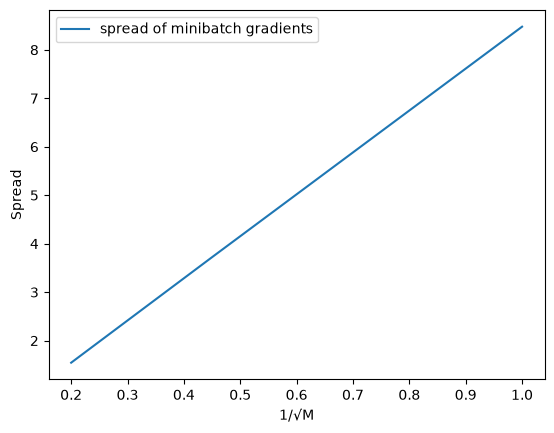

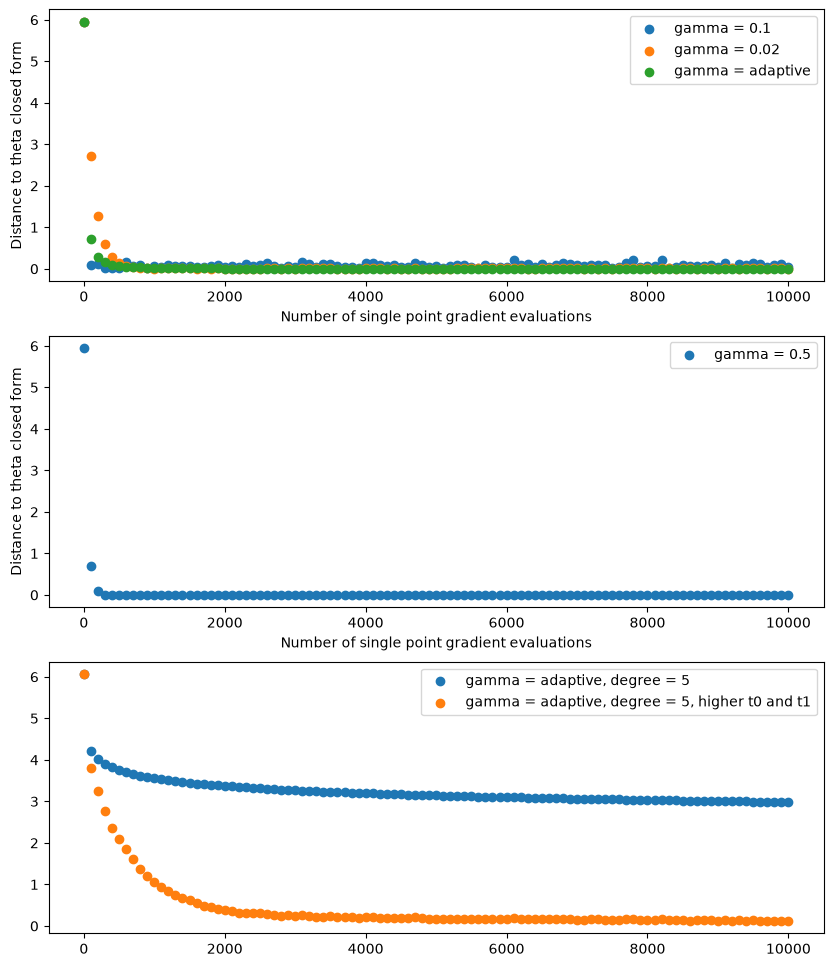

lowest difference to closed form solution for M = 1 : 43.84226480946062
lowest difference to closed form solution for M = 5 : 0.12030944041157904
lowest difference to closed form solution for M = 20 : 0.28514859190307146
lowest difference to closed form solution for M = 100 : 2.059066070631709
The maximum hessian is 85.70382746421875
lowest difference to closed form solution for gamma = 0.01 for adam : 2.871701763573231
lowest difference to closed form solution for gamma = 0.01 for plain : 0.9570298588899921
lowest difference to closed form solution for gamma = 0.01 for momentum : 0.07920236710878631
lowest difference to closed form solution for gamma = 0.05 for adam : 0.14443333451523752
lowest difference to closed form solution for gamma = 0.05 for plain : 0.12454817474149396
lowest difference to closed form solution for gamma = 0.05 for momentum : 3.489948212044466e+19


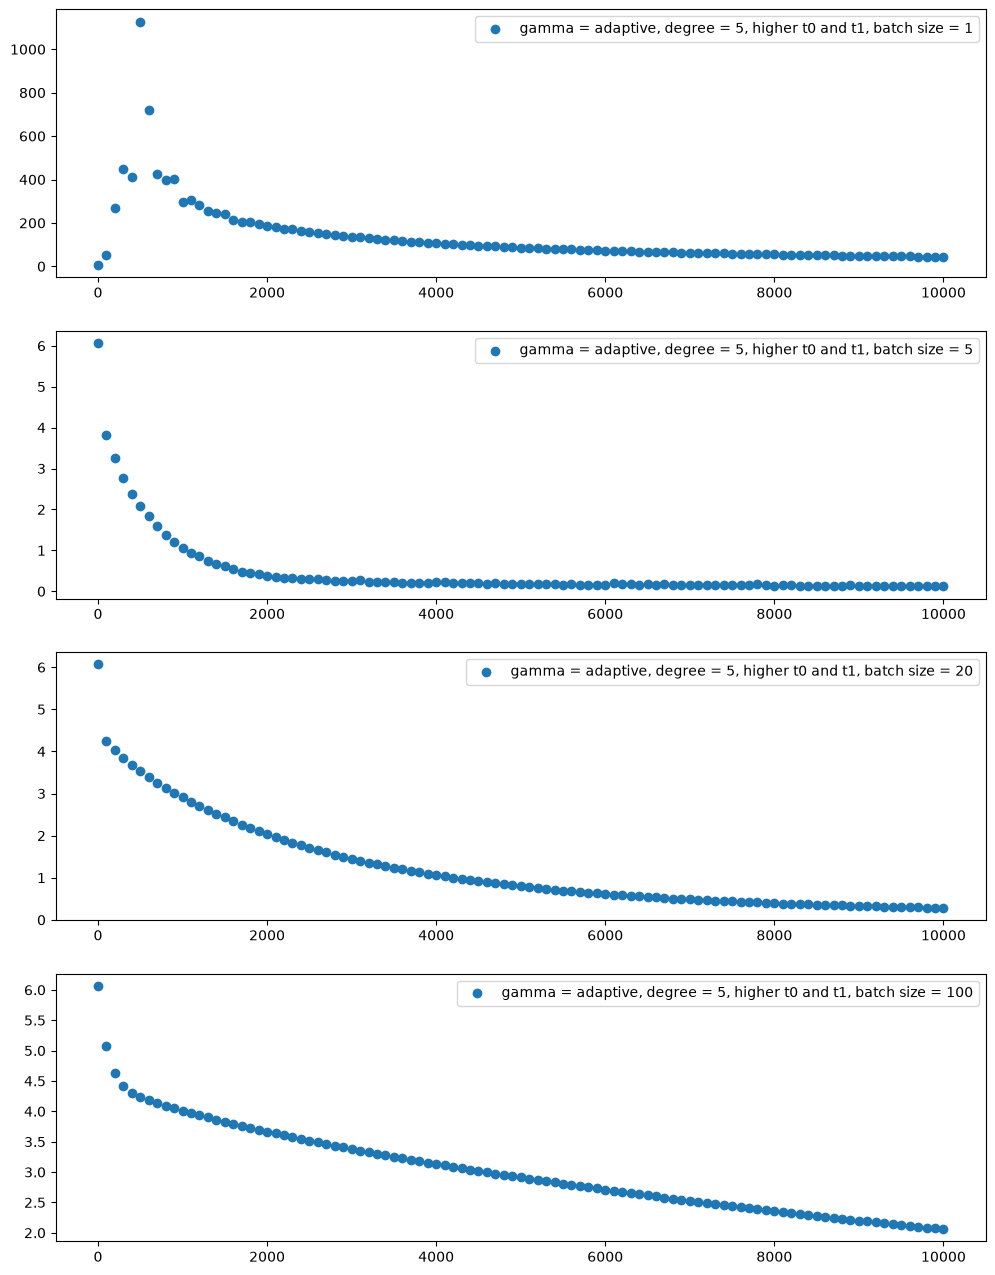

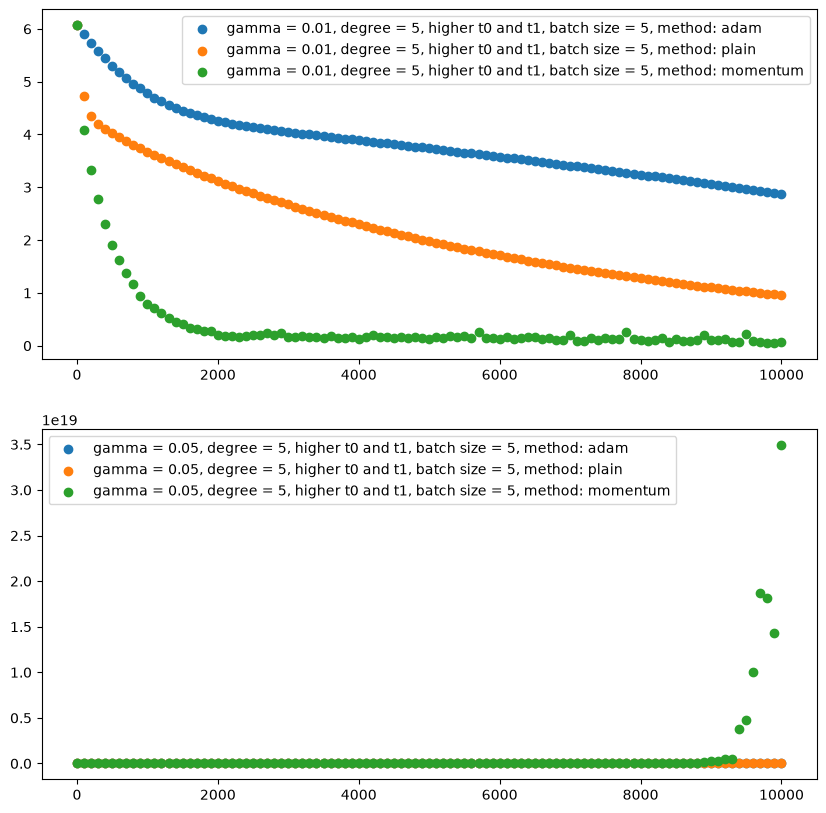

In [22]:
# Your code for exercise 4 here

#a) M = batch_size

n = len(y2)
theta_cf = closed_form(X2, y2)
theta = np.array([0.0, 3.0])
g_full = gradient(theta, X2, y2)
rng = np.random.default_rng(2026)
print("full gradient:", g_full)
spread_batches = np.array([])
i = 0 
for M in (1, 5, 25):
    gs = np.array([gradient(theta, X2[b], y2[b]) for _ in range(40) for b in make_batches(n, M, rng)])
    print(f"M = {M:2d}: mean {np.round(gs.mean(axis=0), 3)}, spread {np.std(gs, axis=0).mean():.3f}")
    spread_batches = np.append(spread_batches, np.std(gs, axis=0).mean())

M = np.array([1,5,25])

fig, ax = plt.subplots()
ax.plot(1/np.sqrt(M), spread_batches, label = "spread of minibatch gradients")
ax.set_xlabel("1/√M")
ax.set_ylabel("Spread")
ax.legend()
plt.show()

#b)

theta_history_g1 = sgd(X2,y2, "plain", 100,5, gamma=0.1)
theta_history_g2 = sgd(X2,y2, "plain", 100,5, gamma=0.02)
theta_history_full = sgd(X2,y2, "plain", 100,100, gamma=0.5)

d_theta_history_g1 = np.linalg.norm(theta_history_g1 - theta_cf, axis=1)
d_theta_history_g2 = np.linalg.norm(theta_history_g2 - theta_cf,axis=1)
d_theta_history_full = np.linalg.norm(theta_history_full - theta_cf,axis=1)

sp_1_2 = np.arange(len(d_theta_history_g1)) * n
sp_full = np.arange(len(d_theta_history_full)) * n

fig, ax = plt.subplots(3,1, figsize=(10,12))

ax[0].scatter(sp_1_2, d_theta_history_g1, label = "gamma = 0.1")
ax[0].scatter(sp_1_2, d_theta_history_g2, label = "gamma = 0.02")
ax[1].scatter(sp_full, d_theta_history_full, label = "gamma = 0.5")
ax[0].set_ylabel("Distance to theta closed form")
ax[1].set_ylabel("Distance to theta closed form")
ax[1].set_xlabel("Number of single point gradient evaluations")
ax[0].set_xlabel("Number of single point gradient evaluations")
ax[0].legend()
ax[1].legend()
#c)
t0,t1 = 1,10 
theta_history_schedule2 = sgd(X2,y2, "plain", 100,5, schedule=(t0,t1))
d_theta_history_schedule2 = np.linalg.norm(theta_history_schedule2 - theta_cf, axis=1)
ax[0].scatter(sp_1_2, d_theta_history_schedule2, label = "gamma = adaptive")
theta_history_schedule5 = sgd(X5,y5, "plain", 100,5, schedule=(t0,t1))
theta_cf = closed_form(X5,y5)
d_theta_history_schedule5 = np.linalg.norm(theta_history_schedule5 - theta_cf, axis=1)
ax[2].scatter(sp_1_2, d_theta_history_schedule5, label = "gamma = adaptive, degree = 5")
ax[2].legend()
theta_history_schedule5_2 = sgd(X5,y5, "plain", 100,5, schedule=(100,1000))
d_theta_history_schedule5_2 = np.linalg.norm(theta_history_schedule5_2 - theta_cf, axis=1)
ax[2].scatter(sp_1_2, d_theta_history_schedule5_2, label = "gamma = adaptive, degree = 5, higher t0 and t1")
ax[2].legend()
ax[0].legend()
plt.show()

#d)
Mm = [1,5,20,100]
fig, ax = plt.subplots(4,1,figsize = (12,16))
j = 0
for m in Mm:

    theta_history = sgd(X5,y5, "plain", 100,m, schedule=(100,1000))
    d_theta_history = np.linalg.norm(theta_history - theta_cf, axis=1)
    print(f'lowest difference to closed form solution for M = {m} : {d_theta_history[-1]}')
    sp_1_2 = np.arange(len(d_theta_history)) * n
    ax[j].scatter(sp_1_2, d_theta_history, label = f"gamma = adaptive, degree = 5, higher t0 and t1, batch size = {m}")
    ax[j].legend()
    j += 1

M1_hessians = np.zeros(100)

for d in range(100):
    M1_hessians[d] = 2*np.linalg.norm(X5[d])**2

print(f'The maximum hessian is {np.max(M1_hessians)}')

#e) 
j = 0
fig, ax = plt.subplots(2,1, figsize = (10,10))
for g in [0.01,0.05]:

    theta_history = sgd(X5,y5, "adam", 100,5, gamma = g)
    d_theta_history = np.linalg.norm(theta_history - theta_cf, axis=1)
    sp_1_2 = np.arange(len(d_theta_history)) * n
    ax[j].scatter(sp_1_2, d_theta_history, label = f"gamma = {g}, degree = 5, higher t0 and t1, batch size = 5, method: adam")
    ax[j].legend()
    print(f'lowest difference to closed form solution for gamma = {g} for adam : {d_theta_history[-1]}')

    theta_history = sgd(X5,y5, "plain", 100,5, gamma = g)
    d_theta_history = np.linalg.norm(theta_history - theta_cf, axis=1)
    sp_1_2 = np.arange(len(d_theta_history)) * n
    ax[j].scatter(sp_1_2, d_theta_history, label = f"gamma = {g}, degree = 5, higher t0 and t1, batch size = 5, method: plain")
    ax[j].legend()
    print(f'lowest difference to closed form solution for gamma = {g} for plain : {d_theta_history[-1]}')

    theta_history = sgd(X5,y5, "momentum", 100,5, gamma = g)
    d_theta_history = np.linalg.norm(theta_history - theta_cf, axis=1)
    sp_1_2 = np.arange(len(d_theta_history)) * n
    ax[j].scatter(sp_1_2, d_theta_history, label = f"gamma = {g}, degree = 5, higher t0 and t1, batch size = 5, method: momentum")
    ax[j].legend()
    print(f'lowest difference to closed form solution for gamma = {g} for momentum : {d_theta_history[-1]}')
    j += 1
    

## Exercise 5: the Runge function at degree 10 (Project 1, parts f and h)

Last week nothing converged on the Runge function $f(x) = 1/(1+25x^2)$ on
$[-1, 1]$ ($n = 100$, noise $0.1$) with a degree-10 polynomial:
$\kappa \approx 2 \times 10^6$. Use the Tuesday session's `runge_data` (the same
standardisation as above).

### 5a)

Run momentum and Adam with the full gradient for 30 000 iterations and plot
the excess cost $C(\boldsymbol{\theta}_k) - C(\hat{\boldsymbol{\theta}}_{\mathrm{OLS}})$
against the iteration. What accuracy do they reach, and does either of them
resolve the flat directions? Explain, with the rotated bowl of the Tuesday
session in mind, why a diagonal rescaling cannot fix a problem whose
ill-conditioning comes from strongly correlated columns.

### 5b)

Add Ridge with $\lambda \in \{10^{-3}, 10^{-2}\}$: what are the condition
numbers now, and how many iterations do momentum and Adam need to reach an
excess cost of $10^{-8}$? Compare the Ridge coefficients with the OLS ones and
discuss whether Ridge is "cheating" — what problem has it solved, and is that
the problem you wanted solved? (Part i) of Project 1 answers the last question
with cross-validation.)

### 5c)

Take one Newton step from $\boldsymbol{\theta}_0 = \boldsymbol{0}$ with the exact
Hessian $\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$ — or, following week 37, with
`jax.hessian` of your cost — and compare with the closed form. What did Newton
use that none of the first-order methods had, and why can we not simply do
this for a neural network?

### 5d)

Finally, minibatches: run SGD with Adam ($M = 10$, a decaying schedule of
your choice, 500 epochs) on the degree-10 problem and compare the excess cost
per gradient evaluation with the full-gradient Adam run of 5a). Give a
critical assessment, in the spirit of part h) of Project 1: what has the noise
bought, and what has it cost?

In [ ]:
# Your code for exercise 5 here

## Insights you should have gained this week — a self-check

Before you hand in, go through the list below without looking at the notes.
Each row is a question we may ask in the Tuesday session or on Project 1; the
right-hand column is the insight it tests, in one sentence.

| Ask yourself | The insight it tests |
|---|---|
| Adam converged for every learning rate from $10^{-3}$ to $1$ and plain gradient descent only in a narrow window. Does $\gamma$ not matter for Adam? | It matters for speed, not for stability: the adaptive step is at most $\gamma$ per coordinate (division by $\sqrt{\hat v}$), so $\gamma$ is a *length in parameter space* and cannot violate Eq. (4.20) — but the best $\gamma$ was still several times faster than the worst. |
| RMSProp at a constant $\gamma$ never reached $10^{-6}$ on a convex quadratic. Why? | Near the minimum $r \approx g^2$ and the step is $\approx \gamma\,\mathrm{sign}(g)$, a fixed length that cannot shrink: the iterate rattles at radius $\sim\gamma$. It needs a decaying $\gamma$ (Eq. 4.40), or the first moment — which is Adam. |
| AdaGrad was slower than plain gradient descent on the degree-6 Runge problem. Is it broken? | No: $\boldsymbol{r}_t$ never forgets, Eq. (4.42), so the effective learning rate decays like $1/\sqrt t$ whether or not the minimum is near. That is the wrong behaviour on a smooth convex problem and the right one for sparse features, which it was designed for. |
| Why does Adam divide its moments by $1 - \beta_i^t$? | Both averages start from zero, so $\mathbb{E}[v_t] = (1-\beta_2^t)\,\mathbb{E}[g^2]$, Eq. (4.53): at $t=1$ the raw second moment is a thousand times too small and the step would be $\sqrt{1000}/\sqrt{10}\approx 3$ times too long. Dividing by the known factor removes the bias exactly; for large $t$ the correction vanishes. |
| What does "adaptive" mean, in one sentence? | Each coordinate gets its own step $\gamma/\sqrt{v_j}$, with $v_j$ the recent mean square gradient as a proxy for the curvature $\lambda_j$: a diagonal, $\mathcal{O}(p)$ imitation of Newton's $\boldsymbol{H}^{-1/2}$ (Section 4.8). |
| Rotating the bowl by $45^\circ$ left plain gradient descent unchanged and made AdaGrad and RMSProp fail. Why? | Eq. (4.19) depends on the eigenvalues only, which a rotation preserves; the adaptive methods rescale *coordinates* and see only the diagonal of $\boldsymbol{H}$. A valley that is not axis-aligned — a correlated polynomial basis, for instance — has its curvature off the diagonal. |
| Every first-order method stalled at an excess cost of $10^{-3}$ on the degree-10 Runge problem, and one Newton step solved it. What did Newton have? | The full Hessian, off-diagonal entries included: $\kappa = 2\times10^6$ is invisible to it, Eq. (4.8). We cannot afford it for a network ($\mathcal{O}(p^3)$); every method from momentum to Adam is a cheaper approximation to it. |
| Book Table 4.1: no optimiser is best at the same $\gamma$ as any other. What does that mean for comparing methods? | A learning rate is not comparable across optimisers — plain descent multiplies the gradient by $\gamma$, the adaptive methods normalise it first. Compare methods at each one's *best* $\gamma$, found by a scan, never at one shared value. |
| Plain SGD with $M=5$ sat at a distance $5\times10^{-2}$ from the minimum for ninety epochs. Has it converged? | No, it has equilibrated: the minibatch gradient is an unbiased estimate with noise $\propto 1/\sqrt M$ (Section 2.5), and at constant $\gamma$ the iterate is a random walk in a cloud of radius $\propto\sqrt\gamma/\sqrt M$. A longer run does not help; a smaller $\gamma$, a larger $M$ or a decaying $\gamma_t$ does. |
| Full-batch gradient descent beat SGD per gradient evaluation on the degree-2 data. Is SGD overrated? | On a small benign problem the exact gradient is cheap and converges geometrically, Eq. (4.26). For $n = 10^6$ one full gradient costs $10^4$ minibatch steps: per unit of computation SGD is far ahead, and it never needs the whole data set in memory — which is why every framework is built on minibatches. |
| The schedule $(t_0,t_1)=(1,10)$ worked at degree 2 and froze at degree 5. Which condition did it break? | Robbins–Monro needs $\sum_t\gamma_t = \infty$; in a finite run $\gamma_t = t_0/(t+t_1)$ with a small $t_1$ decays so fast that the accumulated step cannot cross a $\kappa = 520$ valley. Keep $\gamma_0 = t_0/t_1$ and enlarge both, so the decay starts later. |
| SGD with $M=1$ diverged at a $\gamma$ below $2/\lambda_{\max}$ of the full Hessian. How? | A minibatch step sees the Hessian of the *minibatch* cost; for one point it is $2\boldsymbol{x}_i\boldsymbol{x}_i^T$ with eigenvalue $2\|\boldsymbol{x}_i\|^2$, far above the average. The full-batch bound is a bound on the average, not on every step. |
| When should I stop a stochastic run? | Not on the gradient: monitor the validation cost and stop when it rises while the training cost still falls (early stopping, Section 4.7.1) — a regularisation method as much as a termination rule. |


### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 18 at midnight**. Collaboration is encouraged — list
your collaborators.